# Intital EDA
This is the first pass of EDA on the top articles scraped from Hacker News
## Outline:
 - Import data
 - Look at Missing values
 - Rank vs Score
 - Number of comments vs score


In [80]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

#adjust dataframe display settings
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 500)
#pd.set_option('display.width', 1000)

#Load in raw data
df = pd.read_csv('../data/raw/hn_data.csv')


In [62]:
#Print intial df
print(df.head())
print('\n Describe:')
print(df.describe())
print('\n Data types')
print(df.dtypes)
print('\n Info:')
print(df.info())


            by  descendants        id                                               kids  score        time                                              title   type                                                url text
0   sohkamyung          2.0  43361959                               [43362137, 43362087]     21  1741955104                            A Look at Firefox Forks  story                  https://lwn.net/Articles/1012453/  NaN
1    kristianp         33.0  43360894  [43362149, 43362120, 43361078, 43361378, 43361...     63  1741944238                  AMD's Strix Halo – Under the Hood  story  https://chipsandcheese.com/p/amds-strix-halo-u...  NaN
2  perihelions         19.0  43321109  [43362128, 43361881, 43361684, 43321386, 43361...     58  1741617190  Magpies and Crows Are Using "Anti-Bird Spikes"...  story  https://www.audubon.org/magazine/apparently-ma...  NaN
3       tu7001         11.0  43361309           [43362053, 43361960, 43362023, 43362085]     31  1741949230  Asp

### Missing data: Observations
Columns with missing values: descendants, kids, url, text
- descendants == Nan: the post type does not have comments
- kids == Nan: 
- url == Nan: This is a post on Hacker New's that do not link to anywhere else

In [63]:

#decedants -> int
print(df[df.descendants.isnull()])
print('\n')
print(df[df.kids.isnull()])

#df.descendants.astype('int64')

            by  descendants        id kids  score        time                                              title type                                                url text
7  nicholasjbs          NaN  43361773  NaN      1  1741953633  Recurse Center (YC S10) Is Hiring an Office an...  job  https://recurse.notion.site/Office-Operations-...  NaN


             by  descendants        id kids  score        time                                              title   type                                                url text
7   nicholasjbs          NaN  43361773  NaN      1  1741953633  Recurse Center (YC S10) Is Hiring an Office an...    job  https://recurse.notion.site/Office-Operations-...  NaN
10      Garbage          0.0  43361801  NaN      3  1741953931  Beyond the 70%: Maximizing the human 30% of AI...  story  https://addyo.substack.com/p/beyond-the-70-max...  NaN
21     protik49          0.0  43320194  NaN      3  1741612095              Probabilistic Time Series Forecasting  stor

In [64]:
#Most common post type
count_by_type = df.groupby('type').count().reset_index()
print(count_by_type)

    type  by  descendants  id  kids  score  time  title  url  text
0    job   1            0   1     0      1     1      1    1     0
1  story  99           99  99    93     99    99     99   97     8


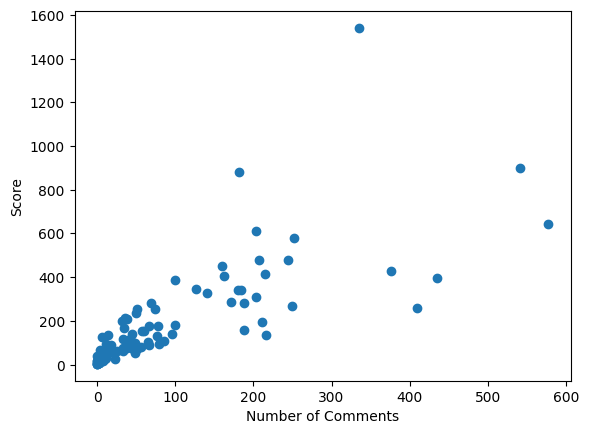

In [66]:
#plot number of comments vs score
plt.scatter(x=df.descendants,y=df.score)
plt.xlabel('Number of Comments')
plt.ylabel('Score')
plt.show()
plt.close()

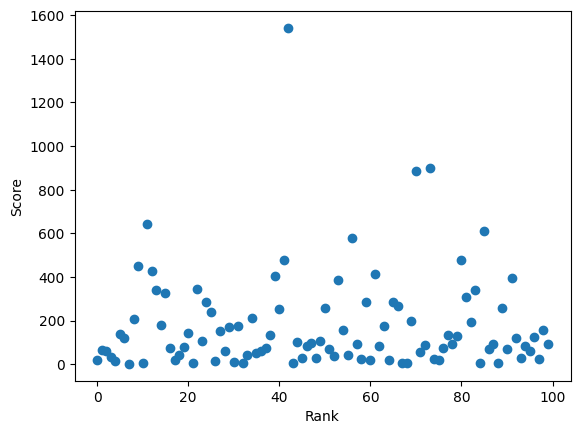

In [73]:
#plot rank vs score
plt.scatter(x=df.index,y=df.score)
plt.xlabel('Rank')
plt.ylabel('Score')
plt.show()
plt.close()

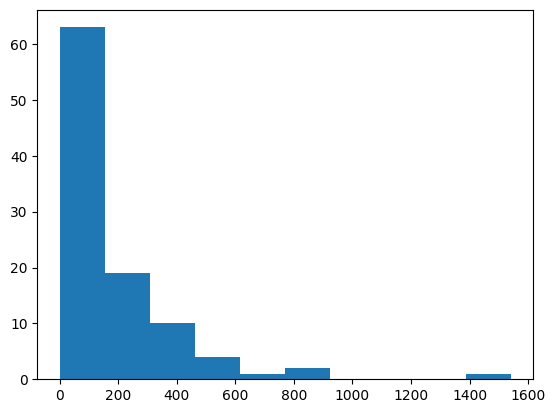

In [68]:
#plot histagraph of article scores
plt.hist(df.score)
plt.show()
plt.close()

               descendants  id  kids  score  time  title  type  url  text
by                                                                       
PaulHoule                2   2     2      2     2      2     2    2     0
Tomte                    5   5     5      5     5      5     5    5     0
birdculture              2   2     2      2     2      2     2    2     0
gmays                    2   2     1      2     2      2     2    2     0
meetpateltech            3   3     3      3     3      3     3    3     0
pseudolus                2   2     2      2     2      2     2    2     0
todsacerdoti             2   2     2      2     2      2     2    2     0


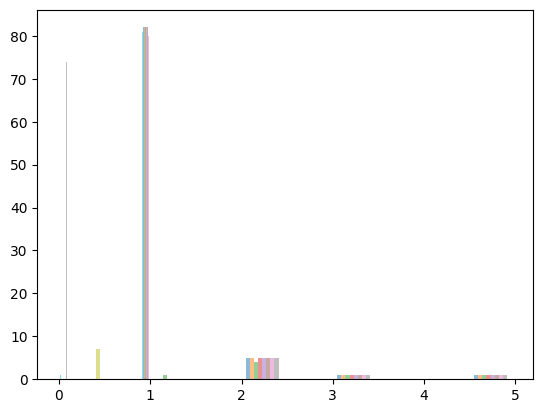

In [72]:
# Averge score compared to total posts by user
count_by_user = df.groupby('by').count()
print(count_by_user[count_by_user.id != 1])
plt.hist(count_by_user[count_by_user.id != 1],label=['Multi-post Users'],alpha=0.5)
plt.hist(count_by_user[count_by_user.id == 1],label=['Single-post Users'],alpha=0.5)
plt.show()
plt.close()

In [ ]:
#Time of day posted vs score and vs rank
#Define Lambda function to take unix code timestamp and return time of day as an interger
get_utc_time_of_day = lambda unix_code_time : int(str(datetime.datetime.fromtimestamp(unix_code_time)).split(' ')[1][:-3].replace(':',''))

#Add time_of_day columns to df
df['time_of_day'] = df.time.apply(get_utc_time_of_day)
print(df.head())

            by  descendants        id                                               kids  score        time                                              title   type                                                url text  time_of_day
0   sohkamyung          2.0  43361959                               [43362137, 43362087]     21  1741955104                            A Look at Firefox Forks  story                  https://lwn.net/Articles/1012453/  NaN          825
1    kristianp         33.0  43360894  [43362149, 43362120, 43361078, 43361378, 43361...     63  1741944238                  AMD's Strix Halo – Under the Hood  story  https://chipsandcheese.com/p/amds-strix-halo-u...  NaN          523
2  perihelions         19.0  43321109  [43362128, 43361881, 43361684, 43321386, 43361...     58  1741617190  Magpies and Crows Are Using "Anti-Bird Spikes"...  story  https://www.audubon.org/magazine/apparently-ma...  NaN         1033
3       tu7001         11.0  43361309           [43362053, 4

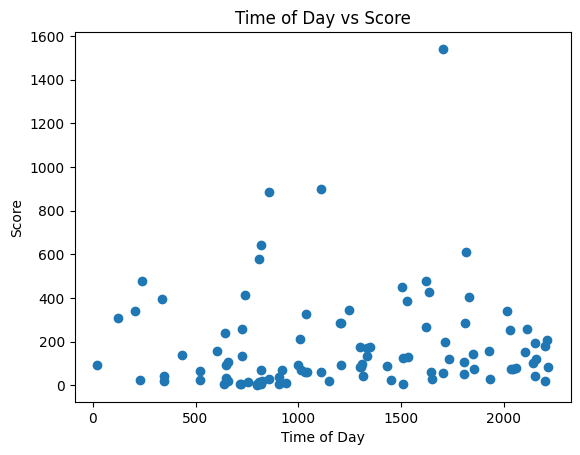

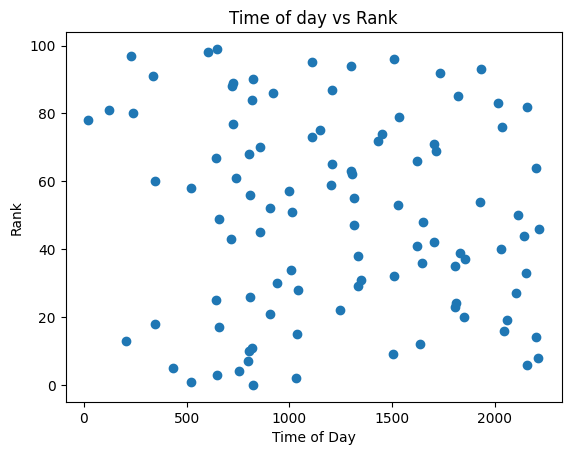

In [89]:
#time of day vs score
plt.scatter(x=df.time_of_day,y=df.score)
plt.title('Time of Day vs Score')
plt.xlabel('Time of Day')
plt.ylabel('Score')
plt.show()
plt.close()
plt.scatter(x=df.time_of_day,y=df.index)
plt.title('Time of day vs Rank')
plt.xlabel('Time of Day')
plt.ylabel('Rank')
plt.show()
plt.close()